# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
- A model is "linear" when its output is a weighted sum of the parameters plus an intercept. It represents a constant rate of change between variables. Linear in the parameters/coefficients, not necessarily in the features.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
- A dummy coefficient is chosen relative to the omitted/reference category. The coefficient then tells you the average difference in y between that group and the reference group, holding everything else constant.

3. Can linear regression be used for classification? Explain why, or why not.
- Yea but it's generally a poor choice. Predictions aren't bounded to [0,1], so they can't be interpreted as probabilities. Linear regression also assumes a constant linear relationship across the range, which doesn't respect the binary nature of class labels.

4. What are signs that your linear model is over-fitting?
- Some signs include training $R^2$ error is much better than test $R^2$ error, there's a large gap in between train and validation loss, coefficients are very large in magnitude.

5. Clearly explain multi-colinearity using the two-stage least squares technique.
- Multicollinearity means two or more features are highly correlated, making it hard to isolate their individual effects. Two-stage least squares illustrates the fix where in Stage 1 you regress the collinear variable on an instrument to extract only its independent variation, then use those clean fitted values in Stage 2 so OLS can finally attribute effects correctly.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
- Since the model only needs to be linear in parameters, you can add polynomial terms: $x^2, x^3$
or apply log/sqrt transform

7. What is the interpretation of the slope coefficient in a linear regression?
- tells you how much y is expected to change for a one-unit increase in x​. Also while holding all other variables constant.

8. Compare the train/test split and $k$-fold cross validation.
- Train/test split  divides the data once into two parts, so you train on one chunk and evaluate on the other, which is fast but it's unreliable since the result depends on which observations happened to land in each split. on the other hand, k-fold cross validation is more robust because it divides the data into k equal folds, trains k separate models each using a different fold as the validation set. then it averages the results to give a much more stable performance estimate at the cost of training k times instead of once.

9. How is the $k$ in $k$-fold cross validation typically selected?
- The most common default is k=5 or k=10. These values typically achieve a good bias-variance tradeoff in the CV estimate itself. Larger k means less bias, more variance, more compute.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/Q1_clean.csv')
df = df.rename(columns={' Neighbourhood': 'Neighbourhood',
                         'Neighbourhood ': 'Neighbourhood'})
df.columns = df.columns.str.strip()
df = df.dropna(subset=['Price', 'Review Scores Rating', 'Neighbourhood'])


1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.


               avg_price  avg_score  count
Neighbourhood                             
Manhattan         183.66      91.80  11763
Staten Island     146.17      90.84     96
Brooklyn          127.75      92.36   8487
Queens             96.86      91.55   1590
Bronx              75.28      91.65    217

Most expensive borough: Manhattan


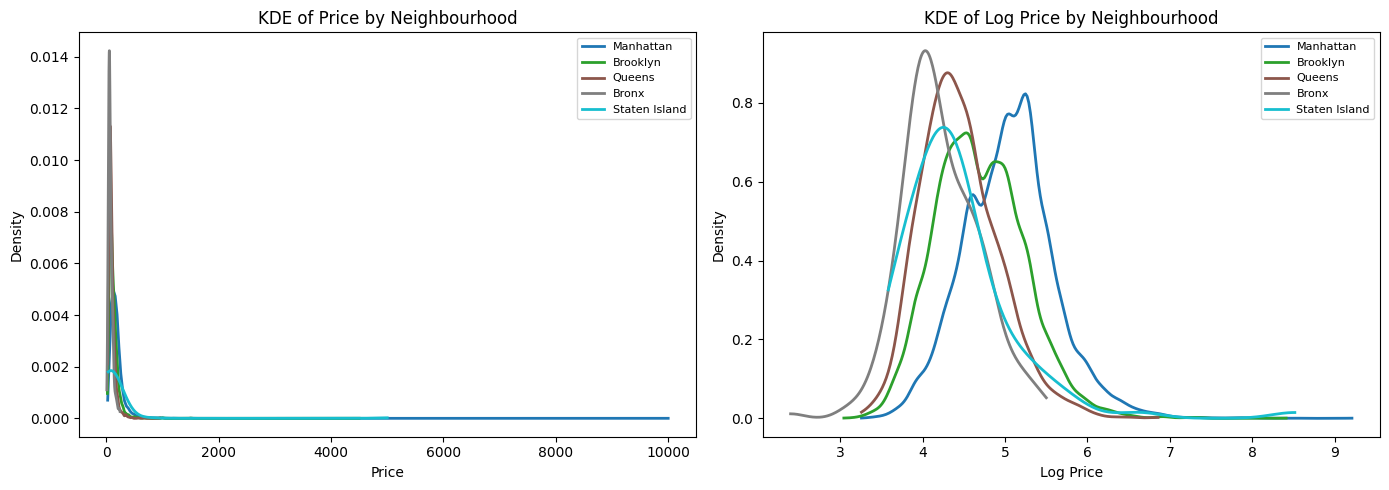

In [106]:
#calculate average price and score by neighbourhood
summary = df.groupby('Neighbourhood').agg(avg_price=('Price', 'mean'),avg_score=('Review Scores Rating', 'mean'),count=('Price', 'count')).round(2)
print(summary.sort_values('avg_price', ascending=False))
print(f"\nMost expensive borough: {summary['avg_price'].idxmax()}")

#kernel density plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
neighbourhoods = df['Neighbourhood'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(neighbourhoods)))

#KDE for Price and log(Price)
for ax, col, title in zip(axes, ['Price', 'log_price'], ['Price', 'Log Price']):
    if col == 'log_price':
        df['log_price'] = np.log1p(df['Price'])
    for nb, color in zip(neighbourhoods, colors): # loop over each borough
        vals = df.loc[df['Neighbourhood'] == nb, col].dropna()
        kde = gaussian_kde(vals)
        x = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(x, kde(x), label=nb, color=color, linewidth=2)
    ax.set_title(f'KDE of {title} by Neighbourhood')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

In [107]:
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=float) #one dummy per borough, drop first to avoid multicollinearity
X2 = sm.add_constant(dummies)
model2 = sm.OLS(df['Price'], X2).fit() #fit OLS: price ~ intercept + borough dummies
print(model2.summary().tables[1])

#verify: intercept == reference group mean, intercept + coef == other group means
ref = sorted(df['Neighbourhood'].unique())[0]
print(f"Reference borough: {ref}")
print(f"Intercept: {model2.params['const']:.2f}    Actual mean: {summary.loc[ref,'avg_price']:.2f}")
for nb in dummies.columns:
    pred = model2.params['const'] + model2.params[nb]
    actual = summary.loc[nb, 'avg_price']
    print(f"{nb}: intercept + coef = {pred:.2f}    actual mean = {actual:.2f}")

                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628      0.000      55.934      94.619
Brooklyn         52.4709      9.994      5.250      0.000      32.883      72.059
Manhattan       108.3878      9.959     10.884      0.000      88.868     127.908
Queens           21.5807     10.520      2.051      0.040       0.960      42.201
Staten Island    70.8902     17.819      3.978      0.000      35.964     105.816
Reference borough: Bronx
Intercept: 75.28    Actual mean: 75.28
Brooklyn: intercept + coef = 127.75    actual mean = 127.75
Manhattan: intercept + coef = 183.66    actual mean = 183.66
Queens: intercept + coef = 96.86    actual mean = 96.86
Staten Island: intercept + coef = 146.17    actual mean = 146.17



3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

In [108]:
model3 = smf.ols('Price ~ Q("Review Scores Rating")', data=df).fit()
print(model3.summary().tables[1])
slope3 = model3.params['Q("Review Scores Rating")']

# Interpretation: A one-point increase in Review Scores Rating is 
# associated with a $1.02 change in nightly price, holding nothing else constant.

                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    60.8784     10.423      5.841      0.000      40.448      81.309
Q("Review Scores Rating")     1.0208      0.113      9.051      0.000       0.800       1.242



4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

In [109]:
model4 = smf.ols('Price ~ Q("Review Scores Rating") + C(Neighbourhood)', data=df).fit()
print(model4.summary().tables[1])

slope4 = model4.params['Q("Review Scores Rating")']
print(f"\nSlope on Review Scores Rating:")
print(f"Model 3 (no controls): {slope3:.4f}")
print(f"Model 4 (with neighbourhood): {slope4:.4f}")
print(f"Change: {slope4 - slope3:.4f}  — controlling for neighbourhood absorbs cross-borough variation in both price and ratings.")

                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -23.8126     14.105     -1.688      0.091     -51.459       3.834
C(Neighbourhood)[T.Brooklyn]         51.7042      9.973      5.185      0.000      32.157      71.251
C(Neighbourhood)[T.Manhattan]       108.2287      9.938     10.891      0.000      88.750     127.707
C(Neighbourhood)[T.Queens]           21.6946     10.498      2.067      0.039       1.119      42.271
C(Neighbourhood)[T.Staten Island]    71.7666     17.781      4.036      0.000      36.915     106.618
Q("Review Scores Rating")             1.0811      0.110      9.812      0.000       0.865       1.297

Slope on Review Scores Rating:
Model 3 (no controls): 1.0208
Model 4 (with neighbourhood): 1.0811
Change: 0.0603  — controlling for neighbourhood absorbs cross-borough variation in bo

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

In [110]:
model5 = smf.ols('Price ~ C(Neighbourhood) * Q("Review Scores Rating")', data=df).fit()
print(model5.summary().tables[1])

#reconstruct each borough's effective slope = base slope + interaction term
ref_nb = sorted(df['Neighbourhood'].unique())[0]
base_slope = model5.params['Q("Review Scores Rating")']
print(f"\nSlopes by neighbourhood (reference = {ref_nb}, base slope = {base_slope:.4f}):")
for nb in sorted(df['Neighbourhood'].unique()):
    if nb == ref_nb:
        print(f"  {nb}: {base_slope:.4f}")
    else:
        interaction_key = f'C(Neighbourhood)[T.{nb}]:Q("Review Scores Rating")'
        if interaction_key in model5.params:
            slope_nb = base_slope + model5.params[interaction_key]
            print(f"  {nb}: {slope_nb:.4f}")

                                                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                      22.6384    110.171      0.205      0.837    -193.305     238.582
C(Neighbourhood)[T.Brooklyn]                                  -16.3930    111.433     -0.147      0.883    -234.810     202.024
C(Neighbourhood)[T.Manhattan]                                  41.3154    111.036      0.372      0.710    -176.322     258.953
C(Neighbourhood)[T.Queens]                                     28.2597    115.168      0.245      0.806    -197.478     253.998
C(Neighbourhood)[T.Staten Island]                            2963.0710    183.986     16.105      0.000    2602.445    3323.697
Q("Review Scores Rating")                                       0.5743      1.197      0.480      0.631 

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [111]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(formula, data, kf):
    rmses = []
    data = data.copy().reset_index(drop=True)
    for train_idx, test_idx in kf.split(data):
        train, test = data.iloc[train_idx], data.iloc[test_idx]
        m = smf.ols(formula, data=train).fit()
        preds = m.predict(test)
        rmse = np.sqrt(np.mean((test['Price'] - preds)**2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

f3 = 'Price ~ Q("Review Scores Rating")'
f4 = 'Price ~ Q("Review Scores Rating") + C(Neighbourhood)'
f5 = 'Price ~ C(Neighbourhood) * Q("Review Scores Rating")'

for label, formula in [('Model 3 (scores only)', f3),
                        ('Model 4 (scores + neighbourhood)', f4),
                        ('Model 5 (interactions)', f5)]:
    mean_rmse, std_rmse = cv_rmse(formula, df, kf)
    print(f"  {label}: RMSE = {mean_rmse:.2f} ± {std_rmse:.2f}")

  Model 3 (scores only): RMSE = 144.17 ± 35.95
  Model 4 (scores + neighbourhood): RMSE = 140.52 ± 36.40
  Model 5 (interactions): RMSE = 141.57 ± 35.87


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

In [112]:
# load
df = pd.read_csv('./data/cars_hw.csv')
df.columns = df.columns.str.strip()
df = df.dropna(subset=['Price', 'Seating_Capacity', 'Body_Type', 'Make_Year'])


  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count        mean        std       min       25%        50%  \
Body_Type                                                                
crossover   21.0   705095.24   72849.78  608000.0  638000.0   706000.0   
hatchback  484.0   533977.27  173086.73  188000.0  401750.0   509000.0   
muv         38.0   626421.05  184093.49  328000.0  489750.0   621500.0   
sedan      227.0   809784.14  286736.77  368000.0  598000.0   772000.0   
suv        206.0  1176495.15  417479.03  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


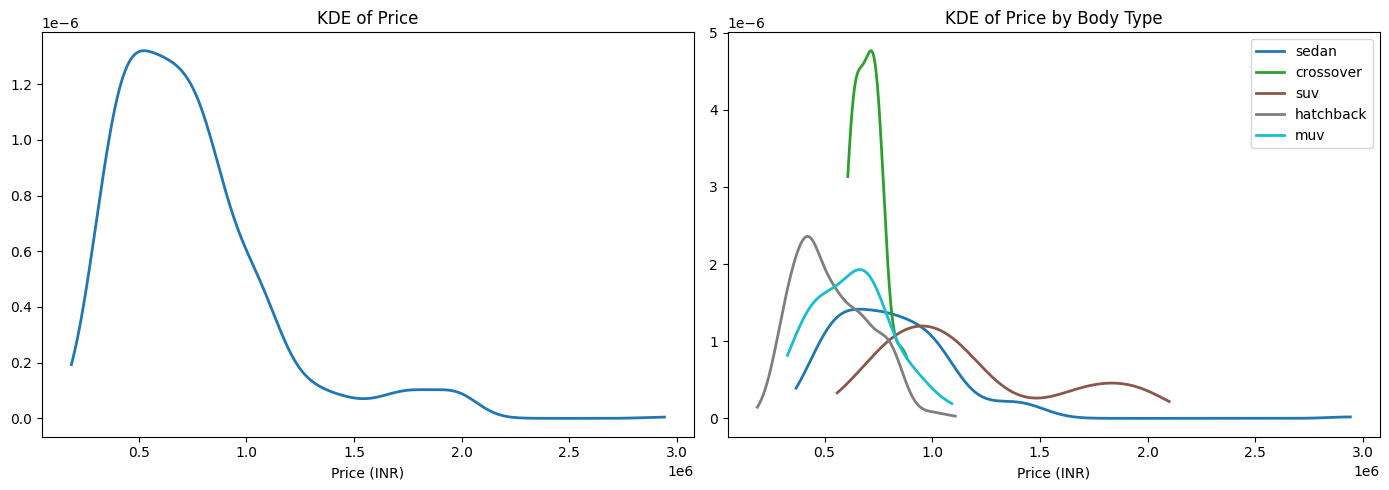

In [113]:
# overall price summary
print(df['Price'].describe())

# summary by body type
print(df.groupby('Body_Type')['Price'].describe().round(2))

# KDE plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
body_types = df['Body_Type'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(body_types)))

# overall price KDE
vals = df['Price'].dropna()
kde = gaussian_kde(vals)
x = np.linspace(vals.min(), vals.max(), 300)
axes[0].plot(x, kde(x), linewidth=2)
axes[0].set_title('KDE of Price')
axes[0].set_xlabel('Price (INR)')

# grouped KDE by body type
for bt, color in zip(body_types, colors):
    vals = df.loc[df['Body_Type'] == bt, 'Price'].dropna()
    kde = gaussian_kde(vals)
    x = np.linspace(vals.min(), vals.max(), 300)
    axes[1].plot(x, kde(x), label=bt, color=color, linewidth=2)
axes[1].set_title('KDE of Price by Body Type')
axes[1].set_xlabel('Price (INR)')
axes[1].legend()

plt.tight_layout()
plt.savefig('part1_kde.png', dpi=150)
plt.show()

#Most expensive body type are SUVS
#Sedans are cheaper on average and more tightly clustered, so lower mean and variance.

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?


In [114]:
# continuous seating capacity
model_cont = smf.ols('Price ~ Seating_Capacity', data=df).fit()
print(model_cont.summary().tables[1])
slope = model_cont.params['Seating_Capacity']

# seating capacity as categorical
model_cat = smf.ols('Price ~ C(Seating_Capacity)', data=df).fit()
print(model_cat.summary().tables[1])

# print group means to compare with coefficients
print(df.groupby('Seating_Capacity')['Price'].mean().round(0))

#the slope is 59,268 INR
#No. the jumps are wildly uneven and non-monotonic

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05      3.263      0.001    1.75e+05    7.03e+05
Seating_Capacity  5.927e+04   2.63e+04      2.253      0.024    7641.189    1.11e+05
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                  1.88e+05   3.64e+05      0.516      0.606   -5.26e+05    9.02e+05
C(Seating_Capacity)[T.5]  5.465e+05   3.64e+05      1.500      0.134   -1.68e+05    1.26e+06
C(Seating_Capacity)[T.6]  1.456e+06   5.15e+05      2.828      0.005    4.46e+05    2.47e+06
C(Seating_Capacity)[T.7]  7.359e+05   3.69e+05      1.996      0.046    1.24e+04    1.46e+06
C(Seating_Capacity)[T.8]  2.718e+05   3.99e+05      0.682      0.496   -5.11e+05    1.05e+06
Seating_C

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 


In [115]:
# create age variable
current_year = 2024
df['Age'] = current_year - df['Make_Year']

# 10-fold CV over polynomial degrees 1-8
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def cv_rmse(formula, data):
    rmses = []
    data = data.reset_index(drop=True)
    for train_idx, test_idx in kf.split(data):
        m = smf.ols(formula, data=data.iloc[train_idx]).fit()
        preds = m.predict(data.iloc[test_idx])
        rmses.append(np.sqrt(np.mean((data.iloc[test_idx]['Price'] - preds)**2)))
    return np.mean(rmses)

results = {}
for deg in range(1, 9):
    # build polynomial formula: Price ~ Age + I(Age**2) + ...
    terms = ' + '.join([f'Age'] + [f'I(Age**{i})' for i in range(2, deg+1)])
    formula = f'Price ~ {terms}'
    results[deg] = cv_rmse(formula, df)
    print(f"Degree {deg}: RMSE = {results[deg]:,.0f}")

best_deg = min(results, key=results.get)
print(f"\nOptimal degree: {best_deg}")

Degree 1: RMSE = 310,765
Degree 2: RMSE = 310,779
Degree 3: RMSE = 309,697
Degree 4: RMSE = 308,872
Degree 5: RMSE = 307,369
Degree 6: RMSE = 307,523
Degree 7: RMSE = 306,433
Degree 8: RMSE = 304,975

Optimal degree: 8


  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


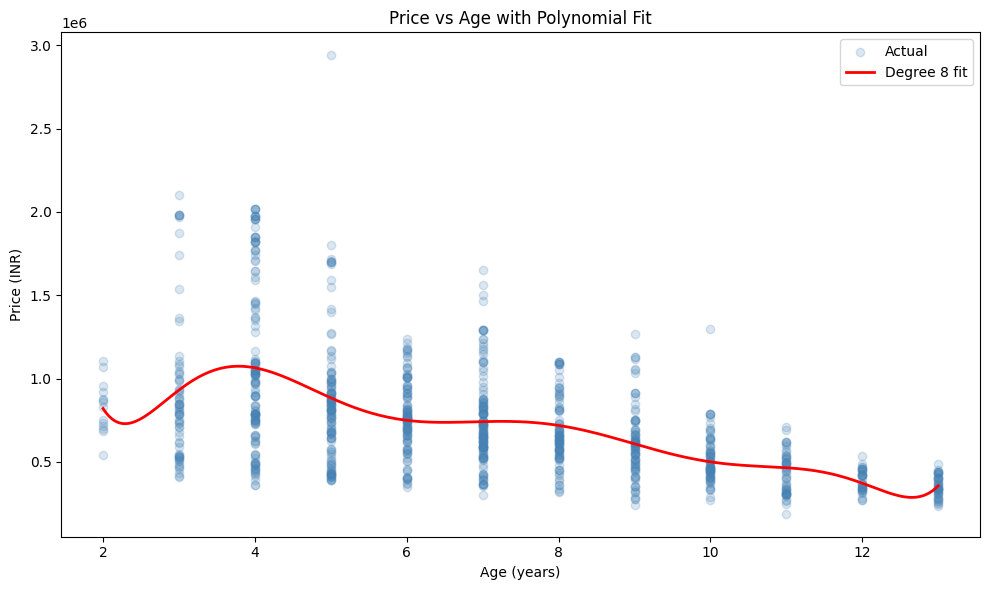

In [116]:
# fit best model on full data
best_terms = ' + '.join(['Age'] + [f'I(Age**{i})' for i in range(2, best_deg+1)])
best_model = smf.ols(f'Price ~ {best_terms}', data=df).fit()

# smooth prediction line
age_range = pd.DataFrame({'Age': np.linspace(df['Age'].min(), df['Age'].max(), 300)})
age_range['predicted'] = best_model.predict(age_range)

# plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Price'], alpha=0.2, color='steelblue', label='Actual')
plt.plot(age_range['Age'], age_range['predicted'], color='red', linewidth=2, label=f'Degree {best_deg} fit')
plt.xlabel('Age (years)')
plt.ylabel('Price (INR)')
plt.title('Price vs Age with Polynomial Fit')
plt.legend()
plt.tight_layout()
plt.show()

#the model correctly captures the pattern of the older the car the cheaper it is.
#however the verticla spread is very large, so predictions for individual cars will be very noisy. 
#at age 4, actual prices range from ~500,000 to 2,000,000 INR, but the fitted line sits around 1,000,000.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

In [117]:
# load
heart = pd.read_csv('./data/heart_hw.csv')
heart.columns = heart.columns.str.strip()
heart = heart.dropna(subset=['y', 'age', 'transplant'])

# encode transplant as binary: treatment=1, control=0
heart['T'] = (heart['transplant'] == 'treatment').astype(int)

control_survival = heart.loc[heart['T'] == 0, 'y'].mean()
treatment_survival = heart.loc[heart['T'] == 1, 'y'].mean()
ate = treatment_survival - control_survival

print(f"Control survival: {control_survival:.3f}")
print(f"Treatment survival: {treatment_survival:.3f}")
print(f"ATE: {ate:.3f}")

Control survival: 0.118
Treatment survival: 0.348
ATE: 0.230



2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 

In [118]:
X = heart[['T']]
model2 = LinearRegression()
model2.fit(X, heart['y'])

print(f"\nIntercept (control mean): {model2.intercept_:.3f}")
print(f"Transplant coef (ATE): {model2.coef_[0]:.3f}")

#the intercept and transplant coefficient numbers are exact same


Intercept (control mean): 0.118
Transplant coef (ATE): 0.230



3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?


Intercept: 0.702
Transplant coef: 0.265
Age coef: -0.014


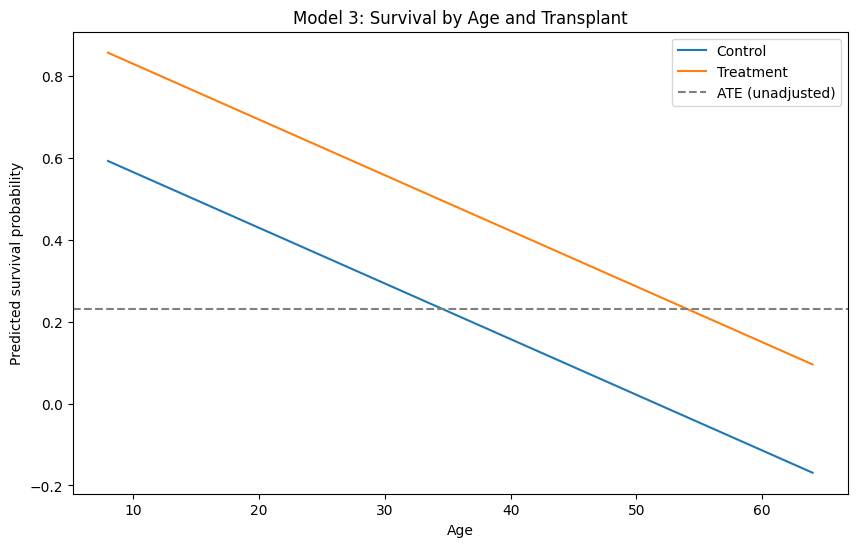

In [119]:
X = heart[['T', 'age']]
model3 = LinearRegression()
model3.fit(X, heart['y'])

print(f"\nIntercept: {model3.intercept_:.3f}")
print(f"Transplant coef: {model3.coef_[0]:.3f}")
print(f"Age coef: {model3.coef_[1]:.3f}")

# plot predicted survival by age
age_range = np.linspace(heart['age'].min(), heart['age'].max(), 300)
pred_control = model3.predict(np.column_stack([np.zeros(300), age_range]))
pred_treatment = model3.predict(np.column_stack([np.ones(300),  age_range]))

plt.figure(figsize=(10, 6))
plt.plot(age_range, pred_control,label='Control')
plt.plot(age_range, pred_treatment,label='Treatment')
plt.axhline(ate, color='gray', linestyle='--', label='ATE (unadjusted)')
plt.xlabel('Age')
plt.ylabel('Predicted survival probability')
plt.title('Model 3: Survival by Age and Transplant')
plt.legend()
plt.show()

#Below ~age 35 and above ~age 50


4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?


Intercept: 0.355
Transplant coef: 0.908
Age coef:-0.006
Interaction coef: -0.015


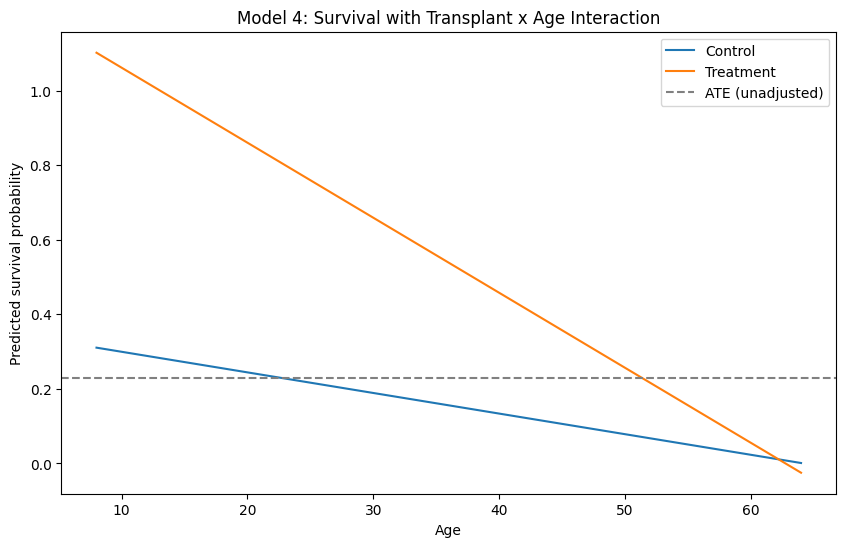

In [120]:
heart['T_age'] = heart['T'] * heart['age']

X = heart[['T', 'age', 'T_age']]
model4 = LinearRegression()
model4.fit(X, heart['y'])

print(f"\nIntercept: {model4.intercept_:.3f}")
print(f"Transplant coef: {model4.coef_[0]:.3f}")
print(f"Age coef:{model4.coef_[1]:.3f}")
print(f"Interaction coef: {model4.coef_[2]:.3f}")

# plot
pred_control = model4.predict(np.column_stack([np.zeros(300), age_range, np.zeros(300)]))
pred_treatment = model4.predict(np.column_stack([np.ones(300),  age_range, age_range]))

plt.figure(figsize=(10, 6))
plt.plot(age_range, pred_control,label='Control')
plt.plot(age_range, pred_treatment,label='Treatment')
plt.axhline(ate, color='gray', linestyle='--', label='ATE (unadjusted)')
plt.xlabel('Age')
plt.ylabel('Predicted survival probability')
plt.title('Model 4: Survival with Transplant x Age Interaction')
plt.legend()
plt.show()

#The lines are no longer parallel, so the treatment line is much steeper than the control line.
#This means the model now captures that transplants help young patients dramatically but the benefit erodes with age.



5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 

In [121]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def cv_rmse(X_cols, data):
    X = data[X_cols].values
    y = data['y'].values
    rmses = []
    for train, test in kf.split(X):
        m = LinearRegression().fit(X[train], y[train])
        preds = m.predict(X[test])
        rmses.append(root_mean_squared_error(y[test], preds))
    return np.mean(rmses), np.std(rmses)

for label, cols in [
    ('Model 2 (transplant only)',['T']),
    ('Model 3 (transplant + age)', ['T', 'age']),
    ('Model 4 (interaction)', ['T', 'age', 'T_age']),
]:
    mean, std = cv_rmse(cols, heart)
    print(f"{label}: RMSE = {mean:.3f} ± {std:.3f}")

Model 2 (transplant only): RMSE = 0.437 ± 0.050
Model 3 (transplant + age): RMSE = 0.417 ± 0.060
Model 4 (interaction): RMSE = 0.413 ± 0.068



6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


The RMSE of every model (0.41-0.44) nearly doubles the ATE (0.23), meaning the prediction error exceeds the effect being measured and the model is too imprecise for individual transplant decisions. The data is observational, so the survival benefit reflects historical selection bias (doctors chose younger, healthier patients for transplants) rather than the true causal effect. Deploying the interaction model would  deny transplants to older patients since the predicted benefit collapses to zero by age 65, raising serious age discrimination concerns. Finally, linear regression is inappropriate here since it produces survival probabilities below zero for older control patients.